# **Vehicle Classification Dataset – KaggleHub Download**


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marquis03/vehicle-classification")

print("Path to dataset files:", path)

100%|██████████| 914M/914M [00:41<00:00, 22.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/vehicle-classification/versions/1


# **Dataset Preparation: Copying Files to `/content`**


In [2]:
import shutil
import os

DST = "/content/vehicle-classification"

os.makedirs(DST, exist_ok=True)

shutil.copytree(
    path,
    DST,
    dirs_exist_ok=True
)

print("Dataset copied to /content successfully!")


Dataset copied to /content successfully!


# **Number of Images per Class (Training Set)**


In [3]:
import os

train_dir = 'vehicle-classification/train'
train_dir_files = os.listdir(train_dir)

for cls_name in train_dir_files:
    cls_fld_dir = f'{train_dir}/{cls_name}'
    num_img_per_cls = os.listdir(cls_fld_dir)
    print(cls_name, "   ",len(num_img_per_cls))


bus     140
minibus     140
SUV     140
family sedan     140
heavy truck     140
truck     140
fire engine     140
taxi     140
racing car     140
jeep     140


# **Dataset Visualization**

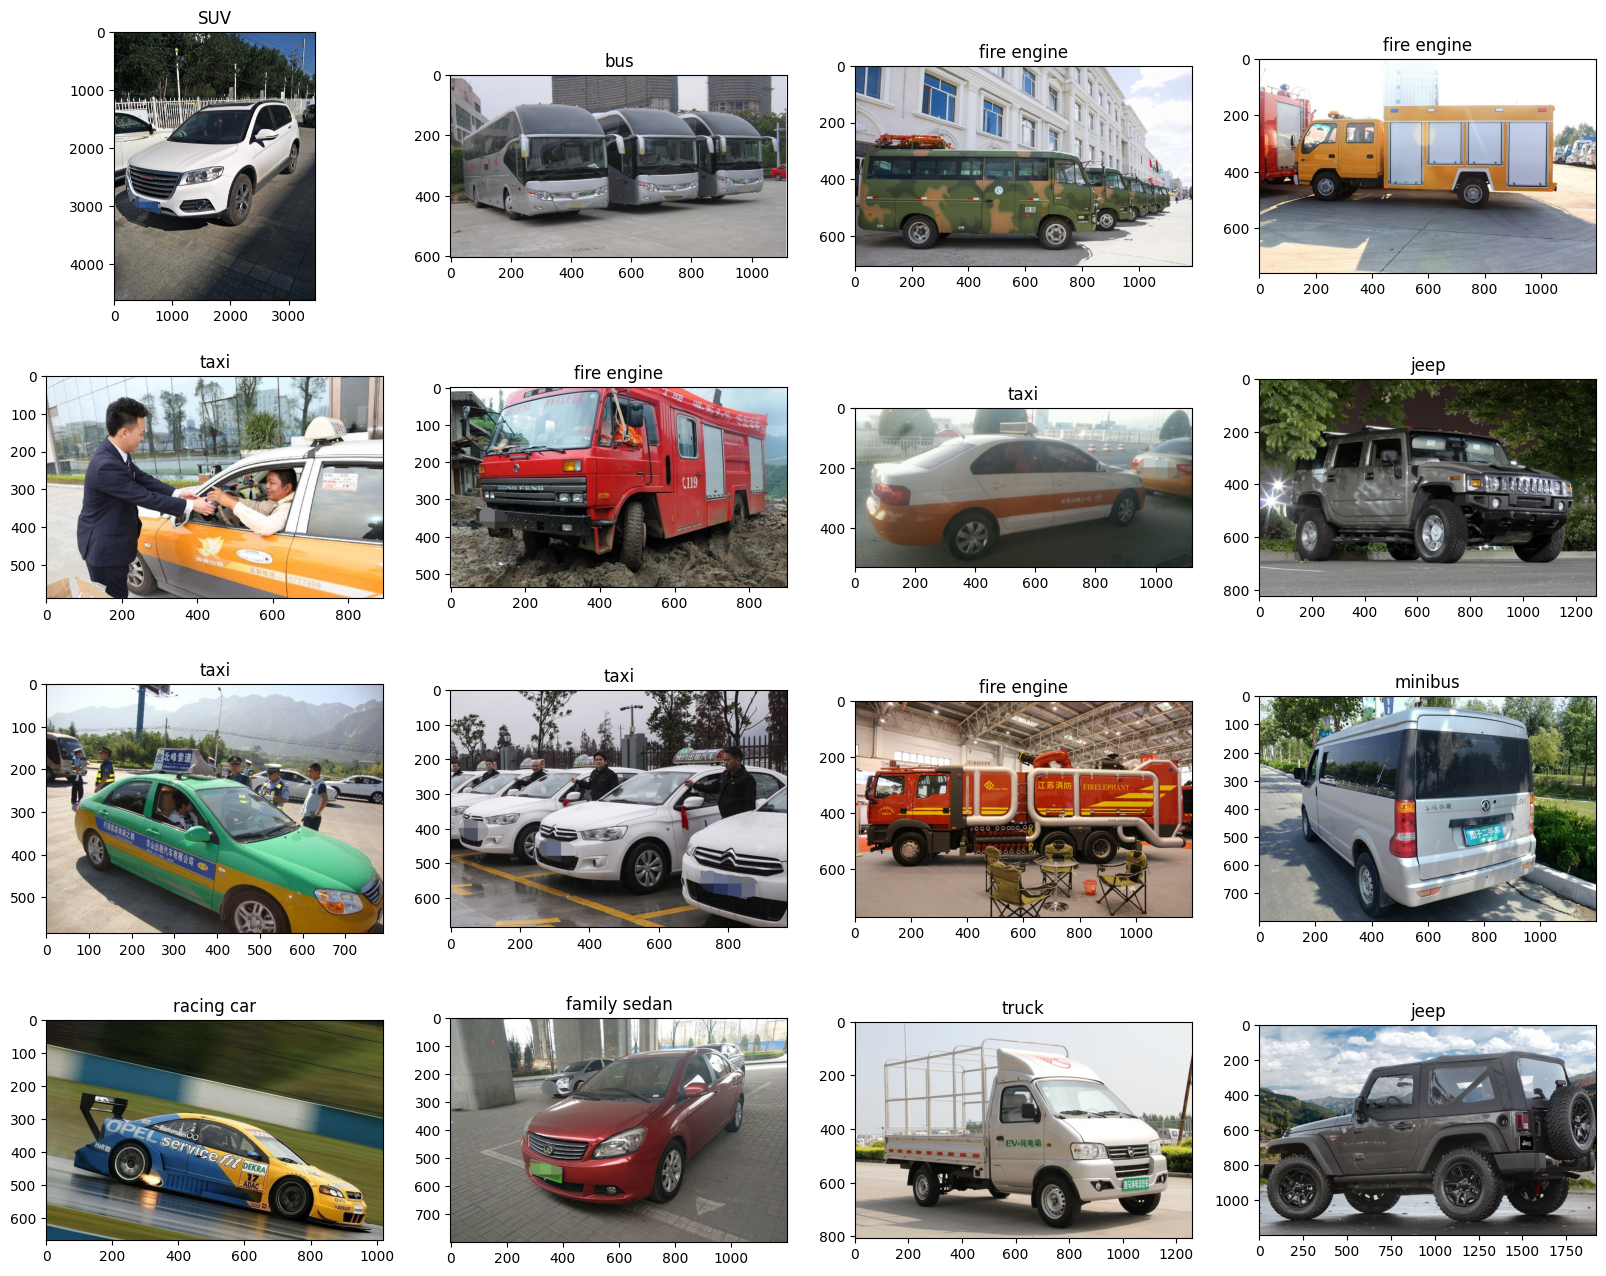

In [4]:
import matplotlib.pyplot as plt
import random
from PIL import Image

fig, ax = plt.subplots(4,4,figsize=(20,16))
ax = ax.ravel()

train_dir_files = os.listdir(train_dir)

for i in range(16):
    cls_name = random.choice(train_dir_files)
    cls_name_files = os.listdir( os.path.join(train_dir,cls_name) )
    img_path = os.path.join(train_dir, cls_name, random.choice(cls_name_files))
    img = Image.open(img_path)

    ax[i].imshow(img)
    ax[i].set_title(cls_name)

plt.show()


#**Install ultra;ytics library**

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.0 MB/s eta 0:00:00


# **Model Training** : **Vehicle Classification Using YOLOv8**

In [6]:
from ultralytics import YOLO

# Load a YOLOv11 classification model
model = YOLO('yolov8l-cls.pt')  # Replace with 'yolo11m-cls.pt' or similar for better accuracy

# Train the classification model
model.train(
    data= 'vehicle-classification',
    epochs=20,
    imgsz=224,
    batch=8,
    name= "vehicle-classification_yolov8",
    save=True,
    save_period=-1,
    patience=20,
    val=True,
    degrees=15,       # Rotation
    flipud=0.3,       # Vertical flip probability
    fliplr=0.5,       # Horizontal flip probability
    scale=0.5,        # Image scaling
    shear=10,         # Shear angle
    translate=0.1     # Translation
)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle-classification, degrees=15, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, ko

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d8239aee960>
curves: []
curves_results: []
fitness: 0.9900000095367432
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9800000190734863, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9900000095367432}
save_dir: PosixPath('/content/runs/classify/vehicle-classification_yolov8')
speed: {'preprocess': 0.21365357500599202, 'inference': 2.968465039999728, 'loss': 0.0007859949994326598, 'postprocess': 0.0015057599989631854}
task: 'classify'
top1: 0.9800000190734863
top5: 1.0

# **Model Performance Evaluation** : **Training Loss & Accuracy Visualization**


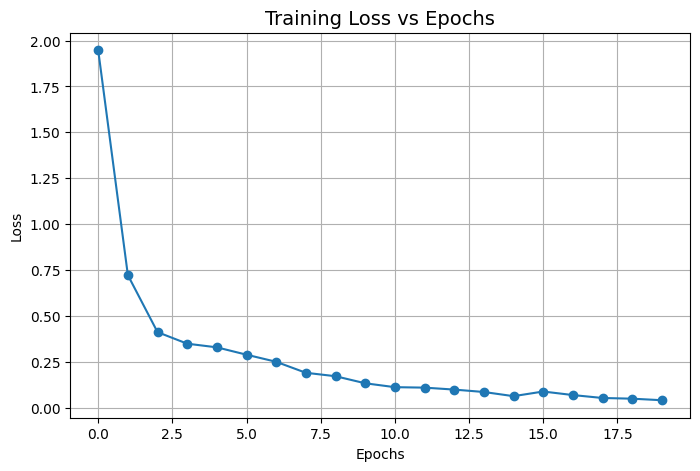

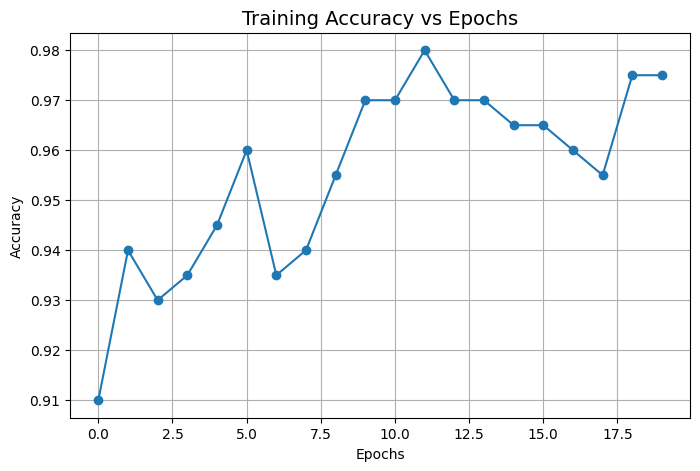

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to results.csv (adjust if needed)
results_path = "runs/classify/vehicle-classification_yolov8/results.csv"

# Load training results
df = pd.read_csv(results_path)

# Clean column names
df.columns = df.columns.str.strip()

# ----------------------------
# Plot Training Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["train/loss"], marker='o')
plt.title("Training Loss vs Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ----------------------------
# Plot Training Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(df["metrics/accuracy_top1"], marker='o')
plt.title("Training Accuracy vs Epochs", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# **Experimental Results** : **Classification Performance on Test Images**



image 1/1 /content/vehicle-classification/test/7be124ec367694c948c57d1e09181775.jpg: 224x224 taxi 1.00, fire engine 0.00, jeep 0.00, heavy truck 0.00, racing car 0.00, 11.2ms
Speed: 10.8ms preprocess, 11.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/vehicle-classification/test/80b2881e21c9323d2693fb73baa063ee.jpg: 224x224 heavy truck 1.00, fire engine 0.00, SUV 0.00, truck 0.00, racing car 0.00, 21.3ms
Speed: 31.7ms preprocess, 21.3ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/vehicle-classification/test/d6086634ce334fe82400a173f0028306.jpg: 224x224 taxi 1.00, family sedan 0.00, racing car 0.00, minibus 0.00, bus 0.00, 12.2ms
Speed: 25.7ms preprocess, 12.2ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)

image 1/1 /content/vehicle-classification/test/1570cbe2a81dd646e94bf5e4e3b1f2b1.jpg: 224x224 fire engine 1.00, family sedan 0.00, heavy truck 0.00, taxi 0.00, minibus 0.00, 11.7ms
S

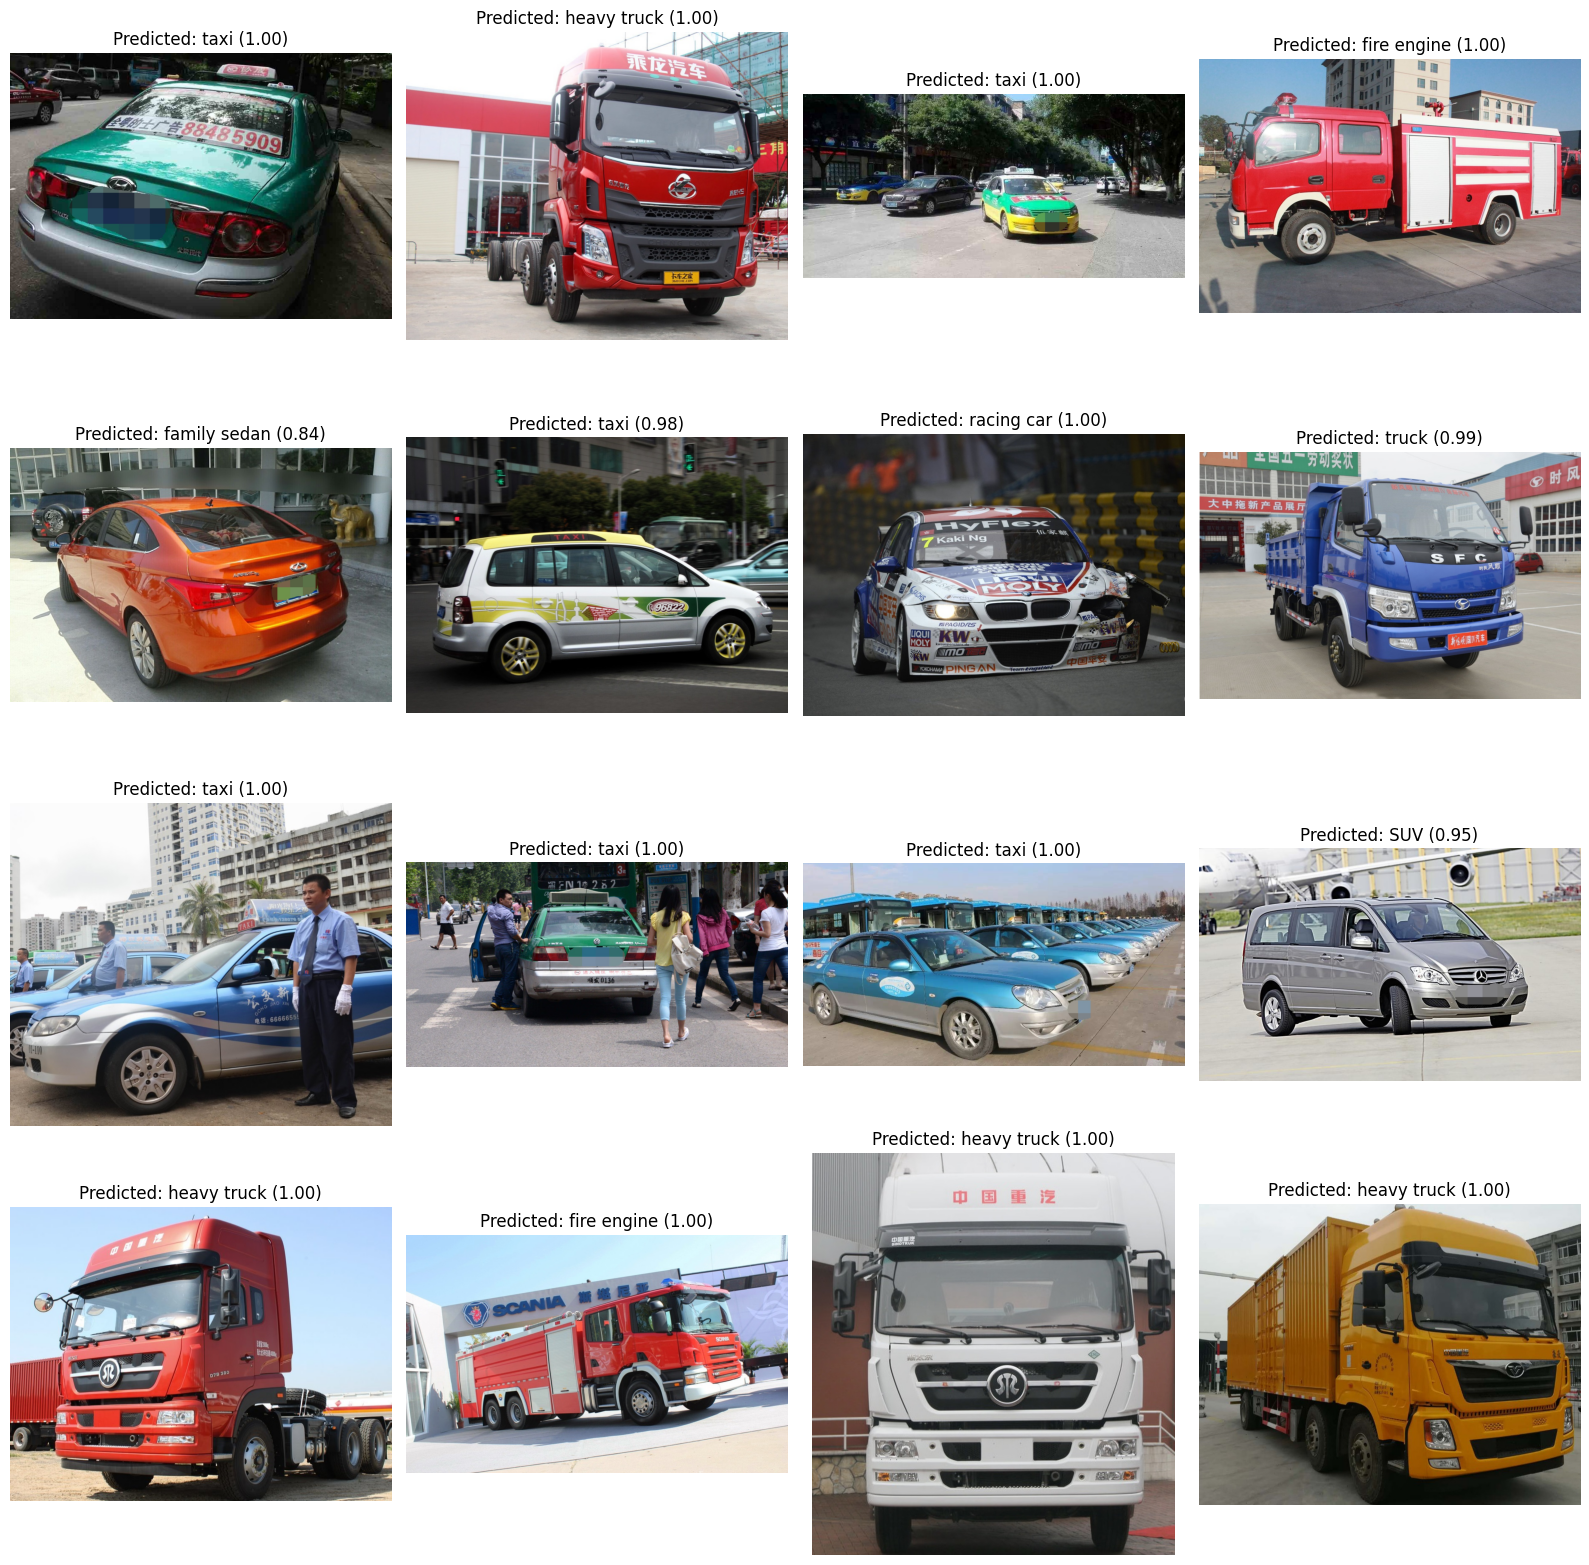

In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random

# Load trained classification model/content/runs/classify/vehicle-classification_yolov8/weights/best.pt
model = YOLO('/content/runs/classify/vehicle-classification_yolov8/weights/best.pt')

# Test images directory
test_images_folders = 'vehicle-classification/test'

# Get list of image files
image_folders = os.listdir(test_images_folders)

# Plot settings
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.ravel()

for idx in range(16):
    img_folder = random.choice(image_folders)
    # img_files = os.listdir(os.path.join(test_images_folders,img_folder))
    img_path = os.path.join(test_images_folders, img_folder)
    # img_path = os.path.join(test_images_folders, img_folder, random.choice(img_files))
    image = cv2.imread(img_path)

    # Perform classification inference
    results = model(img_path)  # returns a list with one result
    result = results[0]

    # Get predicted class name
    class_id = int(result.probs.top1)
    class_name = model.names[class_id]
    confidence = result.probs.top1conf.item()

    # Convert BGR to RGB for plotting
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image with class name and confidence
    ax[idx].imshow(image_rgb)
    # ax[idx].set_title(f"Actual: {img_folder}\n Predicted: {class_name} ({confidence:.2f})", fontsize=12)
    ax[idx].set_title(f"Predicted: {class_name} ({confidence:.2f})", fontsize=12)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()
